# Metabolite cell-cell communication in a tumour microenvironment

The companion tutorial scored metabolism *within* each cell. Here we
ask the next question: in a head & neck tumour, which cell types
**exchange metabolites**? `ov.single.MetaboliteCCC` wraps MEBOCOST to
infer metabolite-mediated cell-cell communication, and reuses the
`ov.pl.ccc_*` communication plots.

## Part.1 The idea behind MEBOCOST

A metabolite-mediated communication event has two ends:

- a **sender** cell type that *produces* a metabolite — read out as
  high expression of that metabolite's synthesising / exporting
  enzymes;
- a **receiver** cell type that *senses* it — high expression of a
  matching **sensor**: a cell-surface receptor, a transporter or a
  nuclear receptor.

MEBOCOST estimates per-cell-type metabolite abundance from enzyme
expression, pairs metabolites with sensors through a curated
database, and scores each sender to receiver event against a
permutation null. Tumour metabolism is not cell-autonomous — malignant
cells, fibroblasts and immune cells feed and starve one another, and
this is how that traffic is mapped.

In [1]:
import omicverse as ov

ov.plot_set()

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
🚫 No GPU devices found (CUDA/MPS/ROCm/XPU)

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## Part.2 The HNSC tumour atlas

The same Puram et al. 2017 head & neck cancer atlas (GSE103322) used
by the per-cell metabolism tutorial — 5,578 cells, malignant plus
the stromal and immune microenvironment.

In [2]:
adata = ov.datasets.metabolism_hnsc()
adata.obs['celltype'].value_counts()

🔍 Downloading data to ./data/hnsc_puram2017_full.h5ad
⚠️ File ./data/hnsc_puram2017_full.h5ad already exists


celltype
Malignant      2215
Fibroblast     1440
T cell         1237
Endothelial     260
B cell          138
Mast            120
Macrophage       98
Dendritic        51
myocyte          19
Name: count, dtype: int64

## Part.3 Infer metabolite communication

`ov.single.MetaboliteCCC` takes the cell-type column as the unit of
communication. `run()` estimates metabolite abundance, pairs
metabolites with sensors and runs the permutation test.
`min_cell_number` drops cell types too small to estimate from, and
`n_shuffle` sizes the null (1000 for a publication; 100 here to keep
the tutorial quick).

In [3]:
mccc = ov.single.MetaboliteCCC(adata, group_key='celltype')
mccc.run(n_shuffle=100, min_cell_number=30, verbose=False)

In [4]:
# every significant metabolite -> sensor communication event
mccc.result[['Sender', 'Receiver', 'Metabolite_Name', 'Sensor',
             'Commu_Score', 'permutation_test_fdr']].head(10)

,Sender,Receiver,Metabolite_Name,Sensor,Commu_Score,permutation_test_fdr
45,Endothelial,Fibroblast,Prostaglandin I2,PTGIR,0.346915,0.0
13,Malignant,Macrophage,Folic acid,FOLR2,0.838808,0.0
9,Malignant,Fibroblast,L-Serine,SLC1A5,0.539551,0.0
14,Malignant,Endothelial,L-Serine,SLC1A5,0.637953,0.0
36,Macrophage,Fibroblast,gamma-Aminobutyric acid,GABBR1,0.692704,0.0
14,Malignant,Endothelial,gamma-Aminobutyric acid,GABBR1,0.706939,0.0
9,Malignant,Fibroblast,gamma-Aminobutyric acid,GABBR1,0.838680,0.0
43,Macrophage,Dendritic,gamma-Aminobutyric acid,GABBR1,0.855080,0.0
5,Fibroblast,Endothelial,Arachidonic acid,SLCO2A1,0.359052,0.0
50,Endothelial,Endothelial,Arachidonic acid,SLCO2A1,0.412114,0.0


## Part.4 Who are the metabolic hubs?

`to_comm_adata()` converts the MEBOCOST result into a communication
AnnData — the schema the `ov.pl.ccc_*` plots consume. The heatmap
sums communication strength over every sender to receiver pair: a
bright row is a metabolite *source*, a bright column a *sink*.

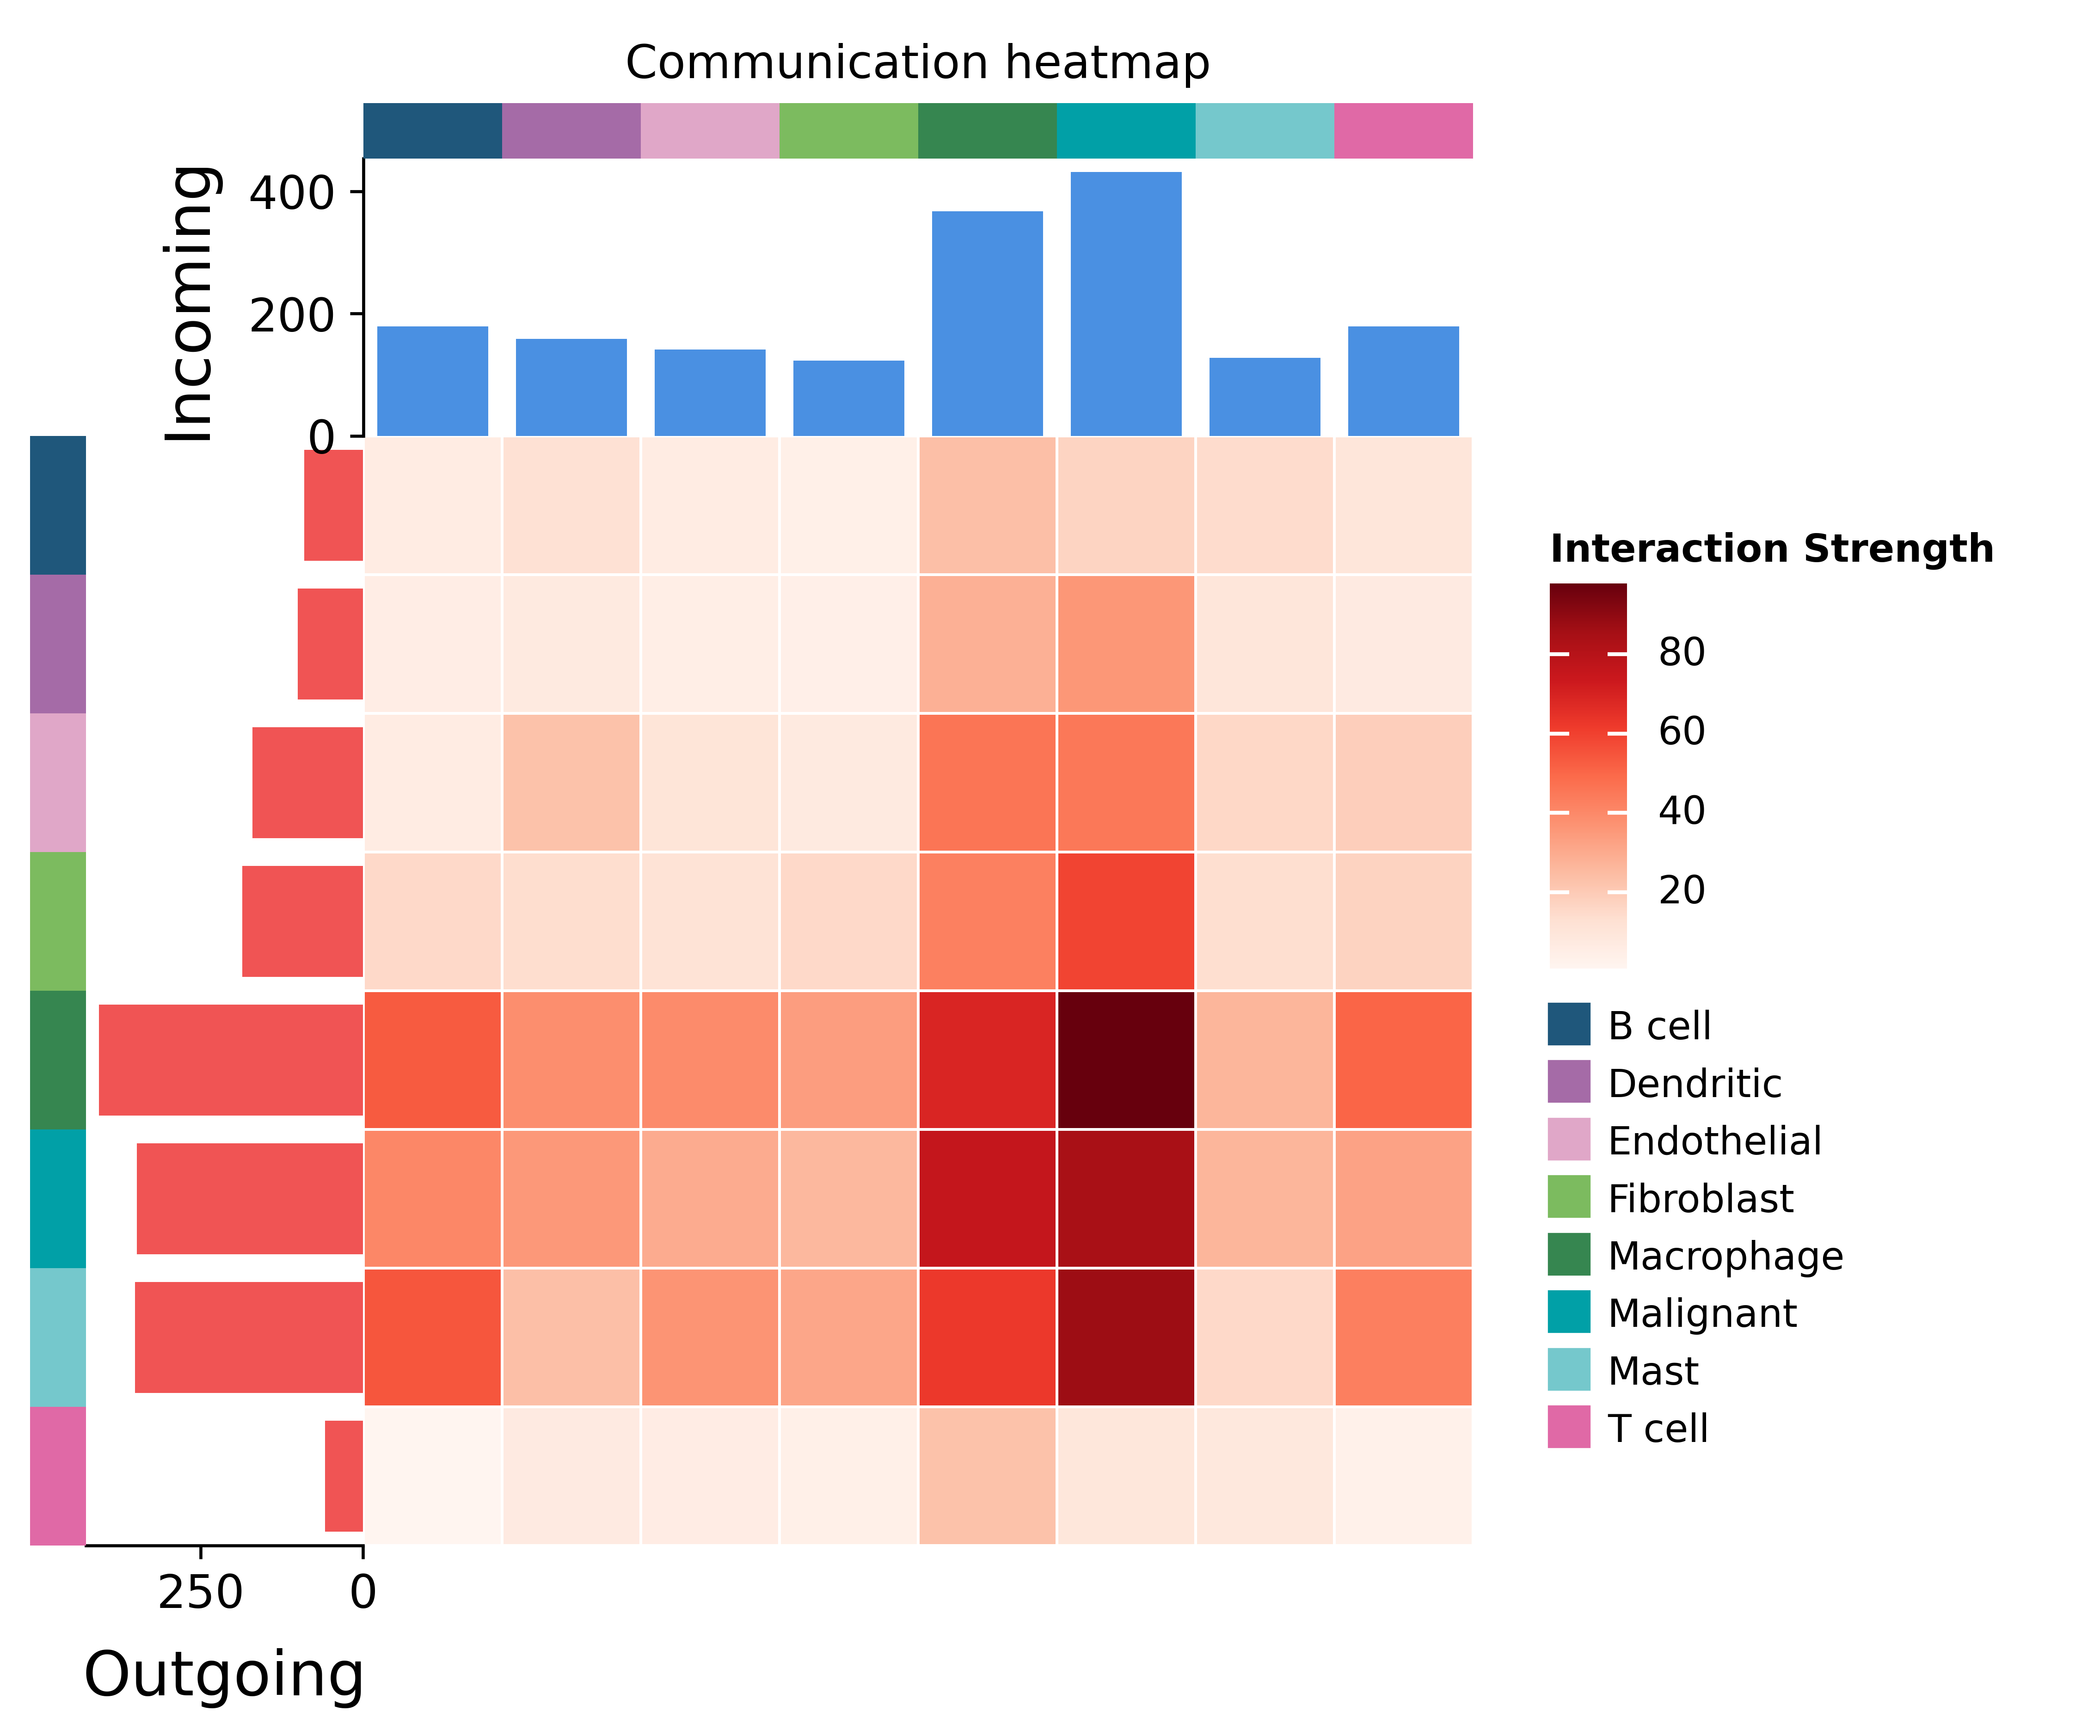

In [5]:
comm = mccc.to_comm_adata()
fig, ax = ov.pl.ccc_heatmap(comm, plot_type='heatmap')
fig

## Part.5 What does the malignant compartment broadcast?

Filtering the result to malignant-cell senders ranks the metabolites
tumour cells release into the microenvironment, and the sensors the
receiving cells use to take them up.

In [6]:
import pandas as pd

mal_out = mccc.result[mccc.result['Sender'] == 'Malignant']
(mal_out.groupby('Metabolite_Name')['Commu_Score'].sum()
        .sort_values(ascending=False).head(10))

Metabolite_Name
L-Glutamine                    115.681047
Iron                            48.373247
Desmosterol                     47.201091
Farnesyl pyrophosphate          33.729001
L-Serine                        24.205057
Prostaglandin E2                14.297269
gamma-Aminobutyric acid         11.547395
Adenine                          8.876420
Adenosine triphosphate           6.731042
Uridine diphosphate glucose      4.886805
Name: Commu_Score, dtype: float64

In [7]:
# the receivers of malignant-derived metabolites
mal_out.groupby('Receiver')['Commu_Score'].sum().sort_values(ascending=False)

Receiver
Malignant      84.032982
Macrophage     75.138486
B cell         39.915346
Dendritic      35.153605
T cell         32.222328
Endothelial    29.341734
Mast           26.382067
Fibroblast     25.518743
Name: Commu_Score, dtype: float64

---

## Recap

`ov.single.MetaboliteCCC` lifts the metabolism analysis from the
single cell to the metabolic *ecology* of the tumour: it names the
metabolite to sensor channels through which cell types signal, scores
them against a permutation null, and hands the result to the same
`ov.pl.ccc_*` plots used for ligand-receptor communication. Paired
with the per-cell **scMetabolism / scFEA** analysis, it completes the
picture — metabolic state *within* cells and metabolite exchange
*between* them.